Dataset shape: (1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


None


Missing Values:


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


Date conversion completed.
Invalid dates: 0

Headline Length Statistics:


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

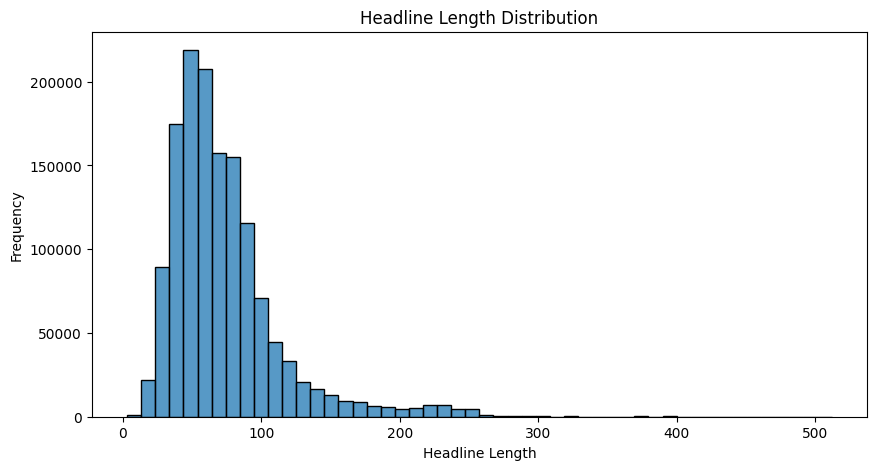


Top 20 Publishers:


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

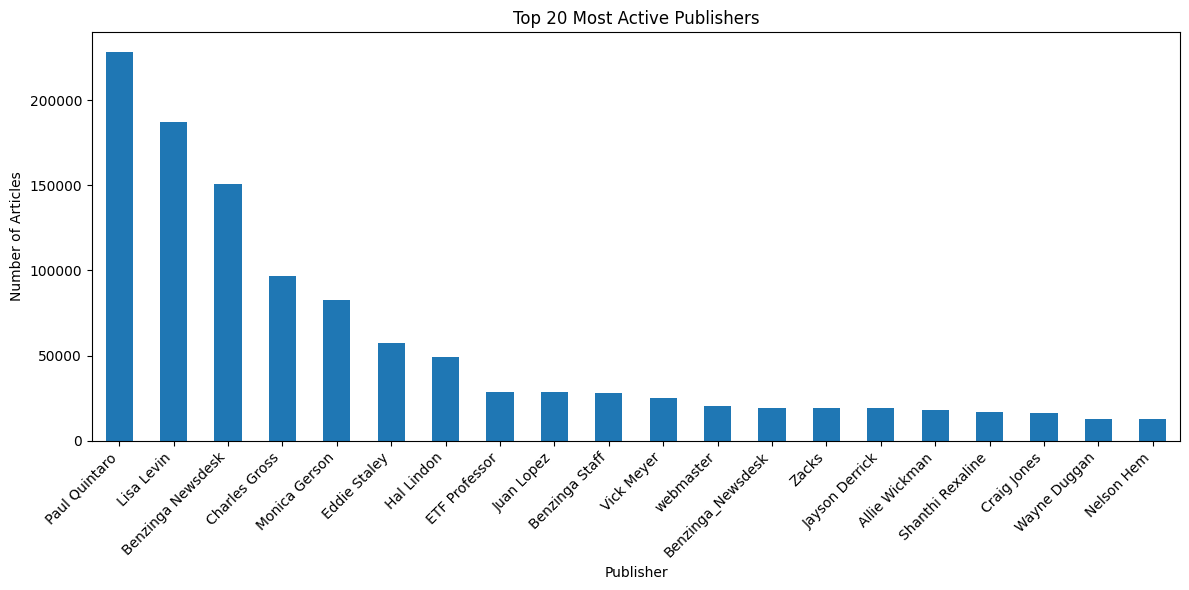


Top Publisher Domains:


publisher_domain
Not Email                 1399240
benzinga.com                 7937
gmail.com                     139
andyswan.com                    5
investdiva.com                  2
tothetick.com                   2
eosdetroit.io                   1
forextraininggroup.com          1
stockmetrix.net                 1
Name: count, dtype: int64

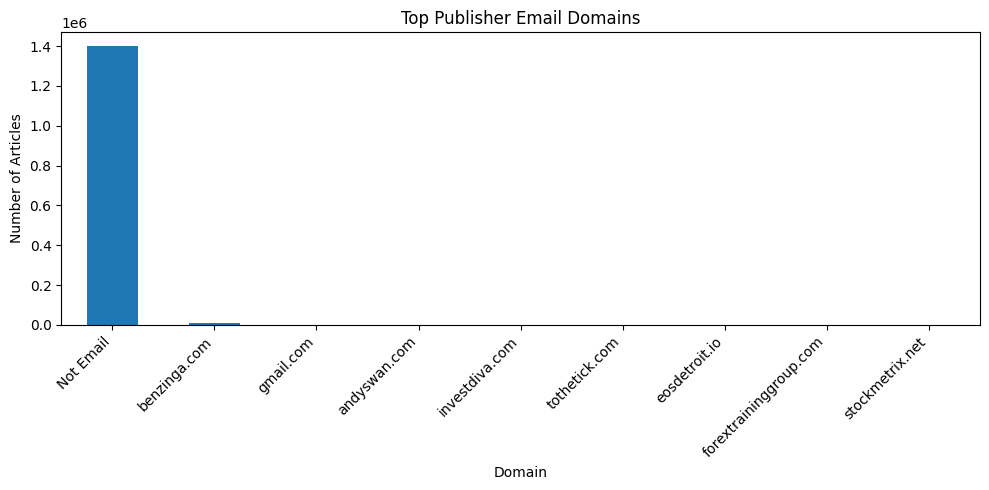


Daily News Volume:


date_only
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64

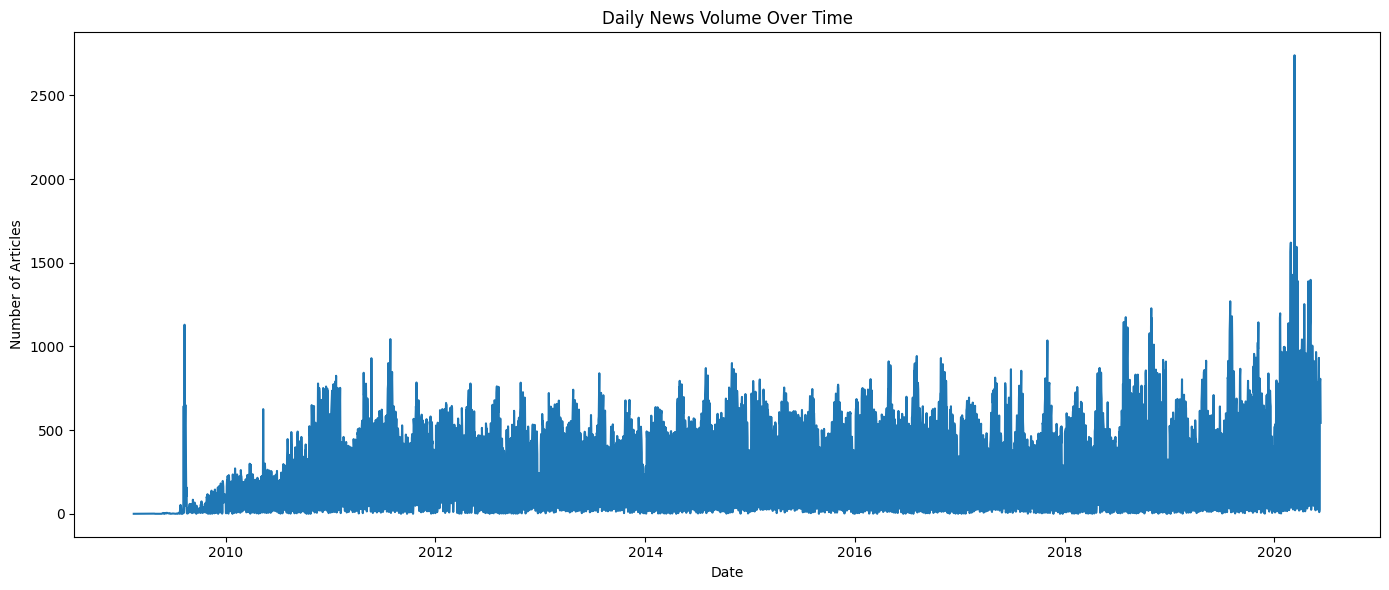


Publishing Hour Counts:


hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
Name: count, dtype: int64

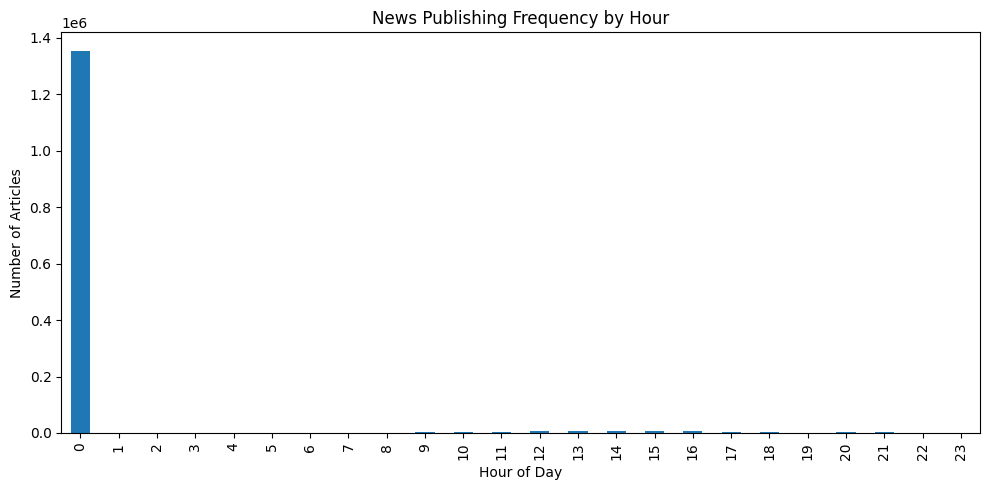


Top 20 Mentioned Stocks:


stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
AA      2739
EWU     2702
ORCL    2701
FDX     2629
HD      2612
Name: count, dtype: int64

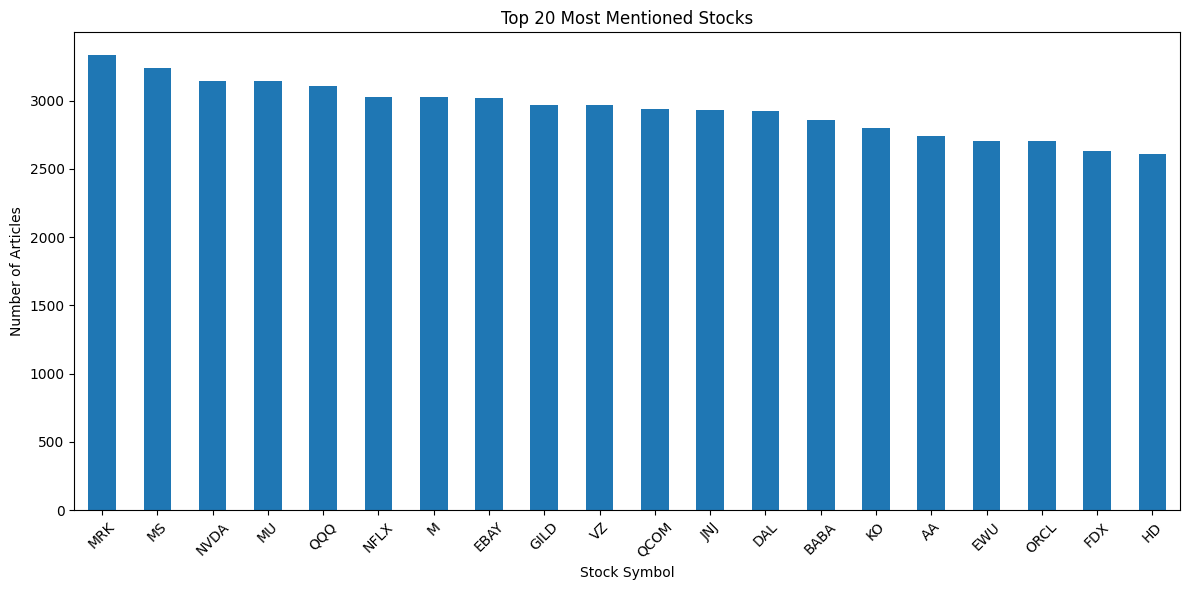


Top Keywords:


,keyword,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


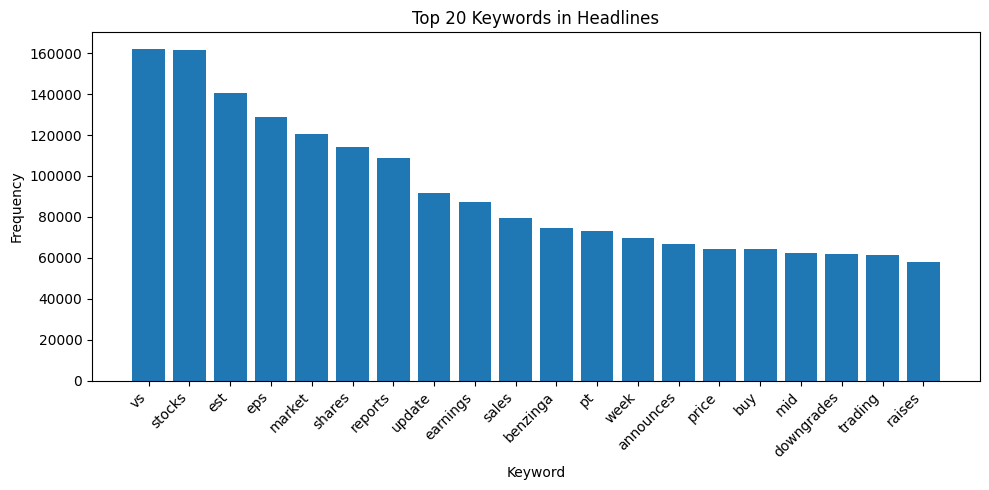


LDA Topics:


,Topic,Top Words
0,Topic 1,"price, pt, announces, buy, raises, target, mai..."
1,Topic 2,"stocks, market, shares, benzinga, week, mid, e..."
2,Topic 3,"vs, est, eps, reports, earnings, sales, q4, se..."


In [1]:

# Task 1: Exploratory Data Analysis
# Financial News Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

# 1. Load Data

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nDataset Info:")
display(df.info())

print("\nMissing Values:")
display(df.isnull().sum())

# 2. Clean Date Column

df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    utc=True,
    errors="coerce"
).dt.tz_localize(None)

df["date_only"] = df["date"].dt.date
df["hour"] = df["date"].dt.hour

print("\nDate conversion completed.")
print("Invalid dates:", df["date"].isna().sum())

# 3. Descriptive Statistics

df["headline"] = df["headline"].astype(str)
df["headline_length"] = df["headline"].apply(len)

print("\nHeadline Length Statistics:")
display(df["headline_length"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["headline_length"], bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

# 4. Publisher Analysis

publisher_counts = df["publisher"].value_counts().head(20)

print("\nTop 20 Publishers:")
display(publisher_counts)

plt.figure(figsize=(12, 6))
publisher_counts.plot(kind="bar")
plt.title("Top 20 Most Active Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Extract publisher domains if publisher is email
df["publisher_domain"] = df["publisher"].astype(str).apply(
    lambda x: x.split("@")[-1] if "@" in x else "Not Email"
)

domain_counts = df["publisher_domain"].value_counts().head(10)

print("\nTop Publisher Domains:")
display(domain_counts)

plt.figure(figsize=(10, 5))
domain_counts.plot(kind="bar")
plt.title("Top Publisher Email Domains")
plt.xlabel("Domain")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5. Publication Trend Over Time

daily_news = df.groupby("date_only").size()

print("\nDaily News Volume:")
display(daily_news.head())

plt.figure(figsize=(14, 6))
daily_news.plot()
plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# 6. Publishing Hour Analysis

hourly_counts = df["hour"].value_counts().sort_index()

print("\nPublishing Hour Counts:")
display(hourly_counts)

plt.figure(figsize=(10, 5))
hourly_counts.plot(kind="bar")
plt.title("News Publishing Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# 7. Most Mentioned Stocks

top_stocks = df["stock"].value_counts().head(20)

print("\nTop 20 Mentioned Stocks:")
display(top_stocks)

plt.figure(figsize=(12, 6))
top_stocks.plot(kind="bar")
plt.title("Top 20 Most Mentioned Stocks")
plt.xlabel("Stock Symbol")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Keyword Analysis

keyword_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

keyword_matrix = keyword_vectorizer.fit_transform(df["headline"])

keyword_counts = pd.DataFrame({
    "keyword": keyword_vectorizer.get_feature_names_out(),
    "count": keyword_matrix.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

print("\nTop Keywords:")
display(keyword_counts)

plt.figure(figsize=(10, 5))
plt.bar(keyword_counts["keyword"], keyword_counts["count"])
plt.title("Top 20 Keywords in Headlines")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 9. Modeling with LDA

count_vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.95,
    min_df=20,
    max_features=500
)

count_data = count_vectorizer.fit_transform(df["headline"])

lda = LatentDirichletAllocation(
    n_components=3,
    learning_method="online",
    random_state=42,
    n_jobs=1,
    max_iter=2
)

lda.fit(count_data)

def print_topics(model, vectorizer, top_n=10):
    words = vectorizer.get_feature_names_out()
    
    topics = []
    
    for topic_idx, topic in enumerate(model.components_):
        top_words = [words[i] for i in topic.argsort()[:-top_n - 1:-1]]
        topics.append({
            "Topic": f"Topic {topic_idx + 1}",
            "Top Words": ", ".join(top_words)
        })
    
    return pd.DataFrame(topics)

topics_df = print_topics(lda, count_vectorizer)

print("\nLDA Topics:")
display(topics_df)